# Two-Point Angular Correlation Cross-Check: sft-wick vs sachsfield MC

We validate the perturbative two-point correlation computation (Feynman diagrams via sft-wick) against direct simulation (ODE evolution on the sphere).

**Observable:** $\xi(\theta, \lambda_f) = \left\langle X(\hat{n}_1, \lambda_f)\, X(\hat{n}_2, \lambda_f) \right\rangle$ where $X(\hat{n}, \lambda) = \int_0^{\lambda} \xi_1(\hat{n}, \lambda')\,d\lambda'$ and $\cos\theta = \hat{n}_1 \cdot \hat{n}_2$.

**Key factorization:** Since $C_\ell^{\rm src}(\tau_1,\tau_2) = \frac{A}{\ell(\ell+1)} e^{-c(\tau_1-\tau_2)^2}$ separates, the dressed C propagator factorizes:
$$C(t_1,t_2;\theta) = S(\theta) \times C_{\rm corr}(t_1,t_2)$$
where $S(\theta) = \sum_\ell \frac{2\ell+1}{4\pi} \frac{A}{\ell(\ell+1)} P_\ell(\cos\theta)$ and $S(0) = S_0$ recovers the one-point result.

**Perturbative structure:**
- Order 0 (tree): 1 diagram $C_{11}(x,y)$, depends on $\theta$ via $S(\theta)$
- Orders 1, 3: **vanish** (odd operator count)
- Order 2: 1-loop corrections (6 diagrams)
- Order 4: 2-loop corrections (64 diagrams)

**MC statistics:** For isotropic fields, `hp.anafast` extracts $C_\ell$ using all pixel information via SHT — the minimum-variance estimator. We compute per-seed $\xi(\theta)$ and average over realizations.

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys, os
from types import SimpleNamespace
from collections import defaultdict
from scipy.interpolate import interp1d, RectBivariateSpline
from scipy.integrate import cumulative_trapezoid
from scipy.special import eval_legendre
import healpy as hp

# sachsfield (add parent to path)
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import sachsfield as sf
from sachsfield.saddle import solve_singular_theta
from sachsfield.fluctuations import FluctuationSolver

# sft-wick
from sft_wick import (
    Field, Vertex, Action, compute_moment, reset_uid_counter,
    PropagatorModel, PropagatorCache, integrate_moment, integrate_diagrams,
)

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

## 1. Parameters

In [55]:
# --- Physical parameters ---
A = 1e-12              # source amplitude (large enough for visible loop corrections)
sbar_1 = -1e-6         # constant background for field 1
c = 0.01               # Gaussian correlation: exp(-c*(lam'-lam'')^2), corr length ~10
lam_f = 3000.0         # integration endpoint
epsilon = 1e-8         # epsilon for solve_singular_theta (saddle only)
lam_start = 0.1        # MC/fluctuation start

# Full-sky grid
nside = 32
lmax = 3 * nside - 1   # = 95
npix = hp.nside2npix(nside)  # = 12288

# --- F tensor ---
F_physical = np.zeros((3, 3, 3))
F_physical[0, 0, 0] = -0.5
F_physical[0, 1, 1] = -2.0
F_physical[0, 2, 2] = -2.0
F_physical[1, 0, 1] = -1.0
F_physical[2, 0, 2] = -1.0
F_code = -1j * F_physical   # MSR convention

# --- Noise kernel amplitude ---
ells = np.arange(1, lmax + 1)
ell_sum = np.sum((2 * ells + 1) / (4 * np.pi * ells * (ells + 1)))
S0 = A * ell_sum

# --- sft-wick field setup ---
phi = Field('phi', 'physical', n_components=3)
psi = Field('psi', 'response', n_components=3)
v = Vertex(fields=[psi, phi, phi], coupling='F')
action = Action(vertices=[v])

# --- Angular separations to probe ---
theta_deg = np.array([1.0, 5.0, 15.0, 45.0])
theta_rad = np.deg2rad(theta_deg)
cos_theta_arr = np.cos(theta_rad)

print(f'A = {A:.2e}, sbar_1 = {sbar_1:.2e}, c = {c}')
print(f'lam_f = {lam_f}, lam_start = {lam_start}')
print(f'nside = {nside}, lmax = {lmax}, npix = {npix}')
print(f'S0 = {S0:.6e}')
print(f'Angular separations: {theta_deg} deg')

A = 1.00e-12, sbar_1 = -1.00e-06, c = 0.01
lam_f = 3000.0, lam_start = 0.1
nside = 32, lmax = 95, npix = 12288
S0 = 7.387264e-13
Angular separations: [ 1.  5. 15. 45.] deg


## 2. Saddle Point and Response Propagator

Solve $d\theta/dt = -\tfrac12 \theta^2 + \bar{s}_1$ with $\theta \sim 2/t$ as $t\to 0^+$.

Then $\Phi(t) = \int_0^t \theta(\tau)\,d\tau$ and $R(t, t') = \exp\!\bigl(\Phi(t') - \Phi(t)\bigr)$.

In [56]:
# --- Solve saddle point ---
t_theta, theta_vals = solve_singular_theta(
    s=lambda t: sbar_1,
    t_max=lam_f,
    epsilon=epsilon,
    num_points=6000,
    method='Radau',
)
print(f'Saddle solved: {len(t_theta)} points in [{t_theta[0]:.2e}, {t_theta[-1]:.1f}]')
print(f'theta(eps) = {theta_vals[0]:.4f},  2/eps = {2/epsilon:.4f}')
print(f'theta(lam_f) = {theta_vals[-1]:.8f}')

# --- Build corrected Phi interpolator ---
t_trans = 5.0
Phi_raw = cumulative_trapezoid(theta_vals, t_theta, initial=0.0)
Phi_analytic_at_trans = 2.0 * np.log(t_trans / epsilon)
k_trans = np.searchsorted(t_theta, t_trans)
Phi_numerical_at_trans = Phi_raw[k_trans]
Phi_offset = Phi_analytic_at_trans - Phi_numerical_at_trans
Phi_corrected = Phi_raw + Phi_offset
Phi_corrected[:k_trans] = 2.0 * np.log(t_theta[:k_trans] / epsilon)
Phi_interp = interp1d(t_theta, Phi_corrected, kind='cubic', fill_value='extrapolate')

print(f'Phi correction: offset = {Phi_offset:.1f}')
print(f'Phi(lam_f) = {Phi_corrected[-1]:.4f}')

# Phi from lam_start (for MC)
t_mc, theta_mc = solve_singular_theta(
    s=lambda t: sbar_1,
    t_max=lam_f,
    epsilon=lam_start,
    num_points=5000,
    method='Radau',
)
Phi_mc_raw = cumulative_trapezoid(theta_mc, t_mc, initial=0.0)
Phi_mc_interp = interp1d(t_mc, Phi_mc_raw, kind='cubic', fill_value='extrapolate')

# --- Response propagator ---
def R_time(t, t_prime):
    """R(t, t') = exp(Phi(t') - Phi(t)) for t > t' > 0, else 0."""
    if t <= 0 or t_prime <= 0 or t <= t_prime:
        return 0.0
    if t < epsilon or t_prime < epsilon:
        return 0.0
    diff = float(Phi_interp(t_prime) - Phi_interp(t))
    if diff < -500:
        return 0.0
    return float(np.exp(diff))

# --- ThetaSaddleResult wrapper for FluctuationSolver ---
class ThetaSaddleResult:
    def __init__(self, t, theta, n_fields=3):
        self.lam = t
        self.n_fields = n_fields
        self._theta_interp = interp1d(t, theta, kind='cubic', fill_value='extrapolate')

    def __call__(self, lam):
        lam_arr = np.asarray(lam, dtype=float)
        scalar = lam_arr.ndim == 0
        lam_arr = np.atleast_1d(lam_arr)
        chi = np.zeros((self.n_fields, len(lam_arr)))
        chi[0] = self._theta_interp(lam_arr)
        return chi[:, 0] if scalar else chi

    def M(self, lam):
        theta_val = float(self._theta_interp(lam))
        return np.diag([-theta_val] * self.n_fields)

theta_saddle = ThetaSaddleResult(t_mc, theta_mc)

print(f'R(10,5) = {R_time(10.0,5.0):.6e}')
print(f'R(1000,500) = {R_time(1000.0,500.0):.6e}')

Saddle solved: 6000 points in [1.00e-08, 3000.0]
theta(eps) = 200000000.0000,  2/eps = 200000000.0000
theta(lam_f) = -0.00086808
Phi correction: offset = -50008300.4
Phi(lam_f) = 51.0316
R(10,5) = 2.496913e-01
R(1000,500) = 2.840514e-01


In [ ]:
# --- Plot saddle point solution theta(lambda) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: full range (log-log to see both 2/t regime and late-time plateau)
ax = axes[0]
ax.plot(t_theta, theta_vals, 'C0-', lw=1.5, label=r'$\theta(\lambda)$')
ax.plot(t_theta, 2.0 / t_theta, 'C1--', lw=1, alpha=0.7, label=r'$2/\lambda$ (analytic)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$\theta(\lambda)$')
ax.set_title('Saddle point solution (log-log)')
ax.legend()

# Right: linear scale at late times to show approach to asymptote
ax = axes[1]
mask_late = t_theta > 100
ax.plot(t_theta[mask_late], theta_vals[mask_late], 'C0-', lw=1.5)
# Asymptotic value: theta -> sqrt(2*|sbar_1|) for constant negative source
theta_asymp = np.sqrt(2 * abs(sbar_1))
ax.axhline(theta_asymp, color='C1', ls='--', lw=1, alpha=0.7,
           label=rf'$\sqrt{{2|\bar{{s}}_1|}} = {theta_asymp:.6f}$')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$\theta(\lambda)$')
ax.set_title('Late-time approach to asymptote')
ax.legend()

plt.tight_layout()
plt.show()

## 3. Direction-Independent C Kernel

Build $C_{\rm corr}(t_1, t_2) = V \cdot G \cdot V^T$ via the matrix method, **without** the $S_0$ angular prefactor. This kernel captures the time-time structure of the noise correlation and response propagation.

The full C propagator at angular separation $\theta$ is then $C(t_1,t_2;\theta) = S(\theta) \times C_{\rm corr}(t_1,t_2)$.

In [57]:
# === Build C_corr table via matrix method (no S0 prefactor) ===
t0_build = time.time()

M_quad = 1000
q = np.linspace(epsilon, lam_f, M_quad)
dq = q[1] - q[0]
Phi_q = Phi_interp(q)

# Gaussian kernel with correlation parameter c
G = np.exp(-c * np.subtract.outer(q, q)**2)  # (M, M)

# Output grid for C table
N_out = 400
ts = np.linspace(epsilon, lam_f, N_out)
Phi_ts = Phi_interp(ts)

# Weight matrix: V[k, m] = exp(Phi(q_m) - Phi(ts_k)) * dq  if q_m <= ts_k
mask_v = q[None, :] <= ts[:, None]  # (N, M)
exponent = np.where(mask_v, Phi_q[None, :] - Phi_ts[:, None], -1e3)
V = np.exp(exponent) * dq  # (N, M)
V[~mask_v] = 0.0

# C_corr: direction-independent kernel (NO S0 prefactor)
C_corr_table = V @ G @ V.T  # (N, N)

# Build spline
C_corr_spline = RectBivariateSpline(ts, ts, C_corr_table)

print(f'C_corr table: {N_out}x{N_out} in {time.time()-t0_build:.1f}s')
print(f'C_corr(lam_f, lam_f) = {C_corr_table[-1, -1]:.6e}')
print(f'Verification: S0 * C_corr(lam_f, lam_f) = {S0 * C_corr_table[-1, -1]:.6e}')
print(f'Symmetric: max|C - C.T| = {np.max(np.abs(C_corr_table - C_corr_table.T)):.2e}')

C_corr table: 400x400 in 0.0s
C_corr(lam_f, lam_f) = 4.956408e+04
Verification: S0 * C_corr(lam_f, lam_f) = 3.661430e-08
Symmetric: max|C - C.T| = 5.09e-11


## 4. Angular Weight $S(\theta)$ and Tree-Level $C_\ell^X$

The angular weight function $S(\theta) = \sum_\ell \frac{2\ell+1}{4\pi} \frac{A}{\ell(\ell+1)} P_\ell(\cos\theta)$ controls the angular dependence of the C propagator.

The tree-level angular power spectrum of $X$ is:
$$C_\ell^{X,(0)} = \frac{A}{\ell(\ell+1)} \int_0^{\lambda_f}\!\int_0^{\lambda_f} C_{\rm corr}(t,t')\,dt\,dt'$$

In [58]:
# --- Angular weight function S(cos_theta) ---
def S_angular(cos_th):
    """S(theta) = sum_ell (2ell+1)/(4pi) * A/(ell*(ell+1)) * P_ell(cos_theta)."""
    result = 0.0
    for ell in range(1, lmax + 1):
        result += (2 * ell + 1) / (4 * np.pi) * A / (ell * (ell + 1)) * eval_legendre(ell, cos_th)
    return result

# Verify S(0 deg) = S0
S_at_zero = S_angular(1.0)
print(f'S(0 deg) = {S_at_zero:.6e}')
print(f'S0       = {S0:.6e}')
print(f'Match: {abs(S_at_zero - S0) / S0:.2e} relative error')

# Compute S at target angular separations
S_vals = np.array([S_angular(ct) for ct in cos_theta_arr])
print(f'\nS(theta) / S0 at target angles:')
for i, th in enumerate(theta_deg):
    print(f'  {th:5.1f} deg: S/S0 = {S_vals[i]/S0:+.6f}')

# --- Tree-level C_ell^X ---
# Integrate C_corr over both time dimensions via quadrature on the table grid
dt_grid = ts[1] - ts[0]
C_corr_integral = np.sum(C_corr_table) * dt_grid**2
print(f'\nC_corr double integral = {C_corr_integral:.6e}')

# Tree-level angular power spectrum
Cl_X_tree = np.zeros(lmax + 1)
for ell in range(1, lmax + 1):
    Cl_X_tree[ell] = A / (ell * (ell + 1)) * C_corr_integral

# Tree-level xi(theta) via Legendre sum
def xi_from_Cl(Cl, cos_th):
    """xi(theta) = sum_ell (2ell+1)/(4pi) * C_ell * P_ell(cos_theta)."""
    result = 0.0
    for ell in range(1, len(Cl)):
        result += (2 * ell + 1) / (4 * np.pi) * Cl[ell] * eval_legendre(ell, cos_th)
    return result

xi_tree_analytic = np.array([xi_from_Cl(Cl_X_tree, ct) for ct in cos_theta_arr])

# Verify: xi_tree should equal S(theta) * C_corr_integral
xi_tree_direct = S_vals * C_corr_integral
print(f'\nTree-level xi(theta) verification:')
for i, th in enumerate(theta_deg):
    print(f'  {th:5.1f} deg: Legendre={xi_tree_analytic[i]:.6e}  '
          f'S*integral={xi_tree_direct[i]:.6e}  '
          f'relerr={abs(xi_tree_analytic[i]-xi_tree_direct[i])/(abs(xi_tree_direct[i])+1e-30):.2e}')

S(0 deg) = 7.387264e-13
S0       = 7.387264e-13
Match: 2.73e-16 relative error

S(theta) / S0 at target angles:
    1.0 deg: S/S0 = +0.930702
    5.0 deg: S/S0 = +0.573300
   15.0 deg: S/S0 = +0.329934
   45.0 deg: S/S0 = +0.099018

C_corr double integral = 4.014357e+10

Tree-level xi(theta) verification:
    1.0 deg: Legendre=2.760007e-02  S*integral=2.760007e-02  relerr=1.26e-15
    5.0 deg: Legendre=1.700129e-02  S*integral=1.700129e-02  relerr=4.08e-16
   15.0 deg: Legendre=9.784236e-03  S*integral=9.784236e-03  relerr=7.09e-16
   45.0 deg: Legendre=2.936388e-03  S*integral=2.936388e-03  relerr=7.38e-16


## 5. TwoPointCache and Custom Integration

The standard `PropagatorCache` assigns one direction to all spatial points. For the two-point function $\langle \phi_1(x) \phi_1(y) \rangle$ where $x$ and $y$ are at different sky directions, we need:

1. A **TwoPointCache** that computes $C(n_1,t_1;n_2,t_2) = S(\hat{n}_1 \cdot \hat{n}_2) \times C_{\rm corr}(t_1,t_2)$
2. A **custom QMC integrator** that assigns different directions to different R-connected groups

In [59]:
class TwoPointCache:
    """Duck-typed PropagatorCache for direction-dependent two-point functions.
    
    Uses the factorization: C(n1,t1; n2,t2) = S(n1.n2) * C_corr(t1,t2) * I_N.
    R propagator is direction-independent (scalar when iso_R=True).
    """
    
    def __init__(self, R_time_func, c_corr_spline, S_angular_func, n_components=3):
        self.model = SimpleNamespace(
            iso_R=True, diag_C=True, n_components=n_components,
            R_time=R_time_func,
        )
        self._R_time = R_time_func
        self._c_corr_spline = c_corr_spline
        self._S_angular = S_angular_func
        self._s_cache = {}  # cache S(cos_theta) for repeated direction pairs
    
    def _get_S(self, n1, n2):
        """Compute S(cos_theta) with caching by direction pair."""
        key = (tuple(n1), tuple(n2))
        if key not in self._s_cache:
            cos_th = float(np.dot(np.asarray(n1), np.asarray(n2)))
            cos_th = np.clip(cos_th, -1.0, 1.0)
            self._s_cache[key] = self._S_angular(cos_th)
        return self._s_cache[key]
    
    def R_time(self, t_left, t_right):
        return self._R_time(t_left, t_right)
    
    def R_product(self, r_pairs, times):
        result = 1.0
        for sl, sr in r_pairs:
            result *= float(self.R_time(times[sl], times[sr]))
        return result
    
    def C_value(self, n1, t1, n2, t2):
        """C_{ab}(n1,t1; n2,t2) = S(n1.n2) * C_corr(t1,t2) * delta_{ab}."""
        N = self.model.n_components
        s_val = self._get_S(n1, n2)
        c_corr = float(self._c_corr_spline.ev(t1, t2))
        C_mat = np.zeros((N, N))
        for a in range(N):
            C_mat[a, a] = s_val * c_corr
        return C_mat
    
    def C_diagonal(self, n, t1, n_prime=None, t2=None):
        """Diagonal [C_{00}, C_{11}, ...] as 1D array."""
        if n_prime is None:
            n_prime = n
        if t2 is None:
            t2 = t1
        s_val = self._get_S(n, n_prime)
        c_corr = float(self._c_corr_spline.ev(t1, t2))
        return np.full(self.model.n_components, s_val * c_corr)


def make_two_point_directions(spatial, n1_vec, n2_vec):
    """Build directions dict mapping R-connected groups to sky directions.
    
    Convention: external point 'x' -> n1_vec, 'y' -> n2_vec.
    Internal vertices inherit direction from their R-chain connectivity.
    """
    directions = {}
    for group in spatial.direction_groups:
        # Get the direction variable name for this group
        any_point = next(iter(group))
        dir_var = spatial.direction_map[any_point]
        # Assign direction based on which external point is in this group
        if 'x' in group:
            directions[dir_var] = tuple(n1_vec)
        elif 'y' in group:
            directions[dir_var] = tuple(n2_vec)
        else:
            # Internal-only group — default to n1 (for disconnected diagrams)
            directions[dir_var] = tuple(n1_vec)
    return directions


def integrate_two_point_qmc(ig, lambda_f, cache, directions,
                             t_min=0.0, n_samples=2**14, seed=None):
    """QMC integration with explicit per-group direction assignment.
    
    Replicates the logic of DiagramIntegrand.integrate_moment_qmc but
    takes a `directions` dict instead of a single direction value.
    """
    from scipy.stats import qmc
    
    spatial = ig.spatial
    int_vars_parents_first = list(reversed(spatial.time_integration_vars))
    ext_vars = list(spatial.external_points)
    all_vars = ext_vars + int_vars_parents_first
    n_ext = len(ext_vars)
    n_total = len(all_vars)
    
    if n_total == 0:
        val = ig.evaluate({}, directions, cache)
        return (val.real, 0.0)
    
    # Build causal parent map
    parent_map = defaultdict(list)
    for earlier, later in spatial.time_orderings:
        if earlier in int_vars_parents_first:
            parent_map[earlier].append(later)
    
    sampler = qmc.Sobol(d=n_total, seed=seed)
    u_samples = sampler.random(n_samples)
    values = np.empty(n_samples)
    span = lambda_f - t_min
    
    for s in range(n_samples):
        u = u_samples[s]
        times = {}
        jacobian = 1.0
        
        # External vars: free in [t_min, lambda_f]
        for k in range(n_ext):
            times[ext_vars[k]] = t_min + u[k] * span
            jacobian *= span
        
        # Internal vars: bounded by causal parents
        for k, var in enumerate(int_vars_parents_first):
            idx = n_ext + k
            parents = parent_map.get(var, [])
            if parents:
                hi = min(times[p] for p in parents if p in times)
            else:
                hi = lambda_f
            lo = t_min
            width = hi - lo
            if width <= 0:
                jacobian = 0.0
                times[var] = lo
            else:
                times[var] = lo + u[idx] * width
                jacobian *= width
        
        if jacobian == 0.0:
            values[s] = 0.0
            continue
        
        result = ig.evaluate(times, directions, cache)
        values[s] = result.real * jacobian
    
    estimate = float(np.mean(values))
    n_batches = 8
    batch_size = n_samples // n_batches
    batch_means = np.array([
        np.mean(values[i*batch_size:(i+1)*batch_size])
        for i in range(n_batches)
    ])
    std_error = float(np.std(batch_means, ddof=1) / np.sqrt(n_batches))
    return (estimate, std_error)

print('TwoPointCache and custom QMC integration defined.')

TwoPointCache and custom QMC integration defined.


## 6. sft-wick Diagram Computation

Observable: $\langle \phi_1(x)\, \phi_1(y) \rangle$ with perturbative expansion up to order 2.

The Feynman diagrams encode:
- **Tree level:** one C propagator $C_{11}(x,y)$
- **Order 1:** vanishes (odd operator count)
- **Order 2:** 1-loop corrections with bubble and chain topologies

In [60]:
# --- Enumerate diagrams ---
perturbative_order = 4

reset_uid_counter()
obs = [phi('1', 'x'), phi('1', 'y')]

t0_enum = time.time()
result_2pt = compute_moment(
    obs, action, order=perturbative_order,
    response_phase=True, diag_R=True, diag_C=True, iso_R=True,
)
print(f'compute_moment(order={perturbative_order}): {time.time()-t0_enum:.1f}s')

# Print diagram count per order
for order in range(perturbative_order + 1):
    dts = result_2pt.diagram_terms(order)
    n_diag = len(dts) if dts else 0
    if n_diag > 0:
        dt0 = dts[0]
        print(f'Order {order}: {n_diag} diagram(s), '
              f'{len(dt0.integration_vars)} int vars, {len(dt0.propagators)} propagators')
    else:
        print(f'Order {order}: 0 diagram(s) (vanishes)')

compute_moment(order=4): 1.6s
Order 0: 1 diagram(s), 0 int vars, 1 propagators
Order 1: 0 diagram(s) (vanishes)
Order 2: 6 diagram(s), 2 int vars, 4 propagators
Order 3: 0 diagram(s) (vanishes)
Order 4: 64 diagram(s), 4 int vars, 7 propagators


Order 0 diagrams:


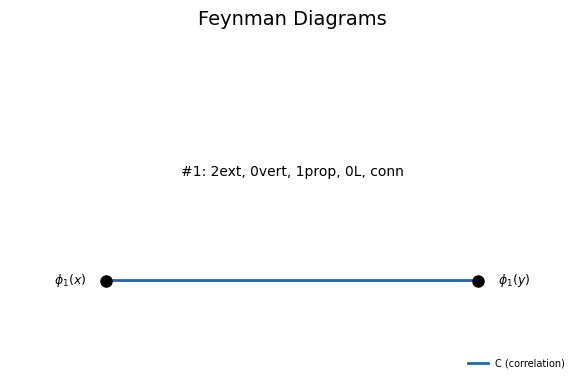


Order 2 diagrams:


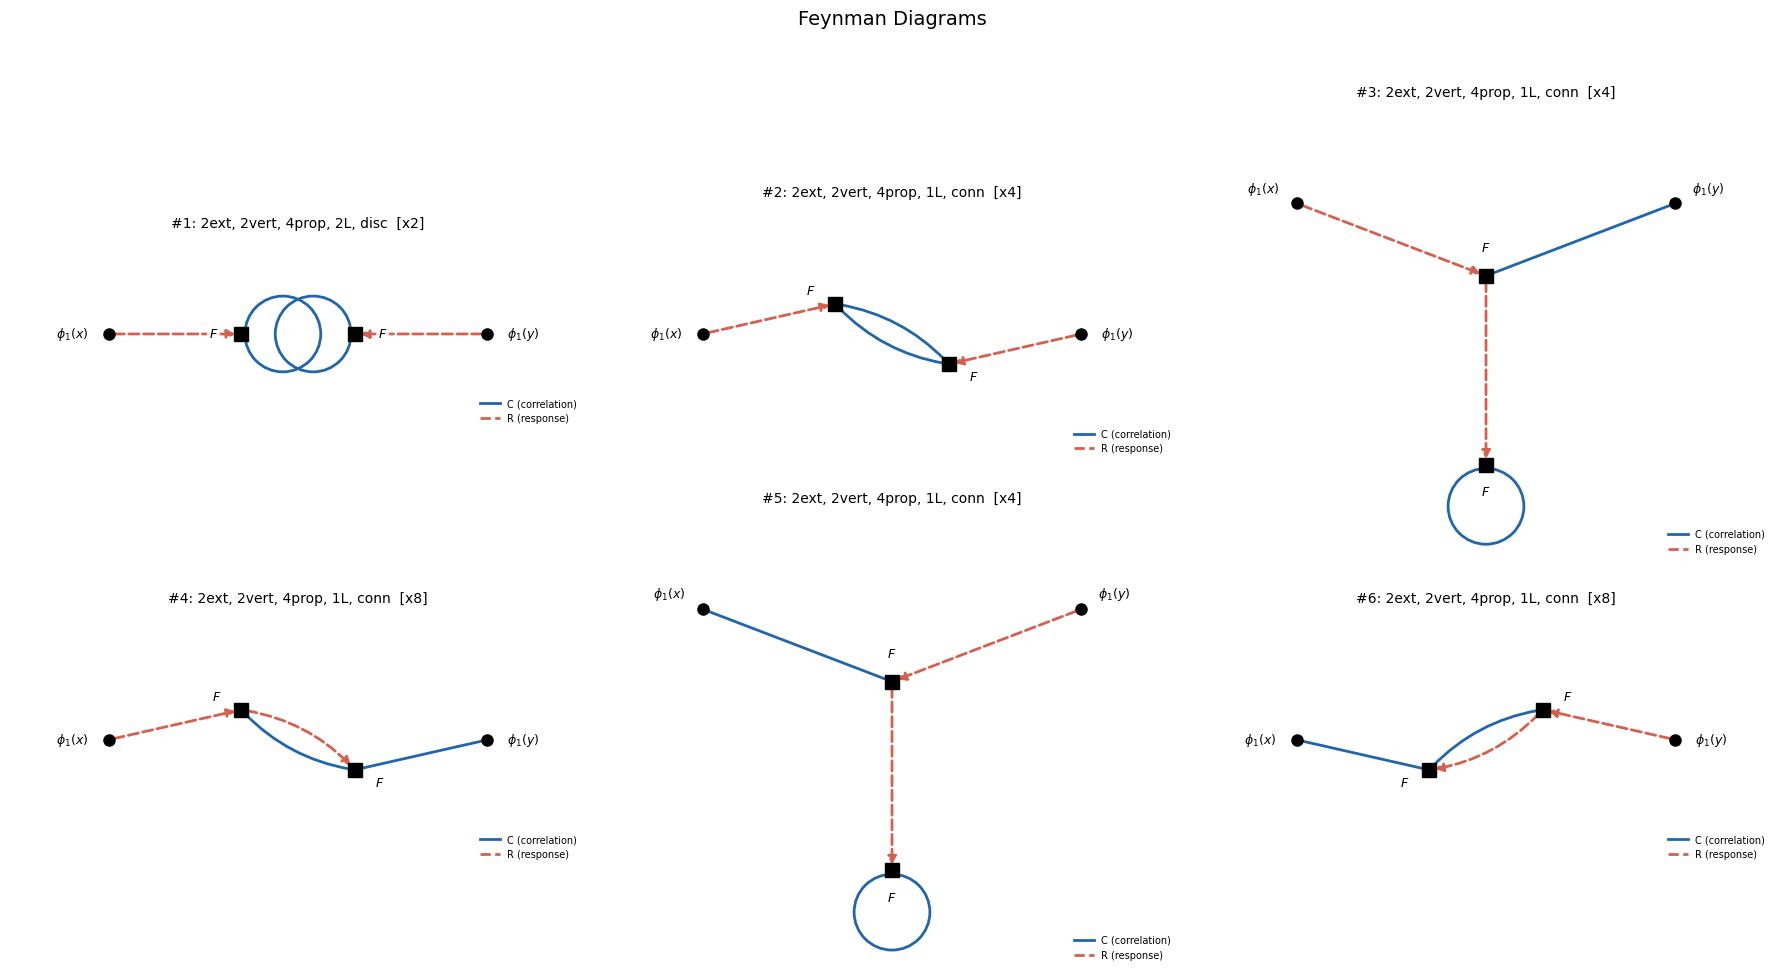


Order 4: 64 diagrams (not drawn)


In [61]:
# --- Visualize diagrams (order 0 and 2 only; order 4 has 64 diagrams) ---
print('Order 0 diagrams:')
result_2pt.draw_diagrams(order=0)
plt.show()

print('\nOrder 2 diagrams:')
result_2pt.draw_diagrams(order=2)
plt.show()

print(f'\nOrder 4: {len(result_2pt.diagram_terms(4))} diagrams (not drawn)')

In [62]:
# --- Integrate diagrams at multiple angular separations ---
n1_vec = np.array([0.0, 0.0, 1.0])  # north pole

# Adaptive QMC samples: higher orders need fewer (corrections are small)
n_samples_by_order = {0: 2**16, 2: 2**14, 4: 2**12}

two_pt_cache = TwoPointCache(R_time, C_corr_spline, S_angular, n_components=3)

xi_wick = np.zeros(len(theta_rad))
xi_wick_tree = np.zeros(len(theta_rad))
xi_wick_breakdown = {}

t0_wick = time.time()
for i_th, th in enumerate(theta_rad):
    n2_vec = np.array([np.sin(th), 0.0, np.cos(th)])
    print(f'\n--- theta = {theta_deg[i_th]:.1f} deg ---')
    
    total = 0.0
    order_bd = {}
    for order in range(perturbative_order + 1):
        dts = result_2pt.diagram_terms(order)
        if not dts:
            continue
        ns = n_samples_by_order.get(order, 2**12)
        
        order_total = 0.0
        order_err_sq = 0.0
        for dt in dts:
            ig = dt.build_integrand({'F': F_code})
            dirs = make_two_point_directions(ig.spatial, n1_vec, n2_vec)
            val, err = integrate_two_point_qmc(
                ig, lam_f, two_pt_cache, dirs,
                t_min=epsilon, n_samples=ns,
            )
            order_total += val
            order_err_sq += err**2
        
        order_bd[order] = order_total
        total += order_total
        print(f'  Order {order}: {order_total:+.6e} +/- {np.sqrt(order_err_sq):.1e}  ({len(dts)} diagrams)')
        
        if order == 0:
            xi_wick_tree[i_th] = order_total
    
    xi_wick[i_th] = total
    xi_wick_breakdown[i_th] = order_bd

print(f'\nsft-wick integration done in {time.time()-t0_wick:.1f}s')

# Cross-check tree level vs analytic
print(f'\nTree-level verification (QMC vs analytic S*integral):')
for i_th, th in enumerate(theta_deg):
    qmc_val = xi_wick_tree[i_th]
    ana_val = xi_tree_direct[i_th]
    relerr = abs(qmc_val - ana_val) / (abs(ana_val) + 1e-30)
    print(f'  {th:5.1f} deg: QMC={qmc_val:.6e}  analytic={ana_val:.6e}  relerr={relerr:.2e}')


--- theta = 1.0 deg ---
  Order 0: +2.740449e-02 +/- 2.7e-08  (1 diagrams)
  Order 2: +7.945353e-03 +/- 3.8e-05  (6 diagrams)
  Order 4: +7.365852e-04 +/- 4.9e-05  (64 diagrams)

--- theta = 5.0 deg ---
  Order 0: +1.688081e-02 +/- 1.6e-07  (1 diagrams)
  Order 2: +6.264788e-03 +/- 3.9e-05  (6 diagrams)
  Order 4: +7.881813e-04 +/- 9.3e-05  (64 diagrams)

--- theta = 15.0 deg ---
  Order 0: +9.714899e-03 +/- 8.0e-07  (1 diagrams)
  Order 2: +5.304234e-03 +/- 2.1e-05  (6 diagrams)
  Order 4: +5.818634e-04 +/- 1.6e-04  (64 diagrams)

--- theta = 45.0 deg ---
  Order 0: +2.915579e-03 +/- 8.5e-09  (1 diagrams)
  Order 2: +4.597296e-03 +/- 4.0e-05  (6 diagrams)
  Order 4: +3.218066e-04 +/- 6.1e-05  (64 diagrams)

sft-wick integration done in 61.6s

Tree-level verification (QMC vs analytic S*integral):
    1.0 deg: QMC=2.740449e-02  analytic=2.760007e-02  relerr=7.09e-03
    5.0 deg: QMC=1.688081e-02  analytic=1.700129e-02  relerr=7.09e-03
   15.0 deg: QMC=9.714899e-03  analytic=9.784236e-0

## 7. sachsfield Monte Carlo

Evolve the full nonlinear equation using `FluctuationSolver(linear_only=False)`, integrate $\xi_1$ to get $X(\hat{n})$, then compute $C_\ell^X$ via `hp.anafast`.

In [63]:
# --- Source power spectrum ---
def cl_func(lam):
    cl = np.zeros(lmax + 1)
    ell = np.arange(1, lmax + 1)
    cl[1:] = A / (ell * (ell + 1))
    return cl, cl.copy(), cl.copy()

corr_func = lambda dlam: np.exp(-c * dlam**2)

# --- Lambda sampling ---
lam_samples = np.linspace(lam_start, lam_f, 200)
dlam_grid = lam_samples[1] - lam_samples[0]
n_lam = len(lam_samples)
print(f'{n_lam} lambda samples in [{lam_samples[0]:.2f}, {lam_samples[-1]:.1f}]')

# --- MC realization: returns full X(n_hat) map ---
def run_realization_map(seed):
    """Run one realization, return the full X(n_hat) healpy map."""
    source = sf.FullSkySource(
        cl_func=cl_func, lam_samples=lam_samples, nside=nside,
        corr_func=corr_func, seed=seed, n_fields=3,
    )
    source.generate()
    delta_s = source.delta_s_interpolator()
    
    fl = FluctuationSolver(
        theta_saddle, delta_s, source.npix,
        n_fields=3, linear_only=False,
        lam_span=(lam_start, lam_f),
        method='RK45', rtol=1e-6, atol=1e-12,
    )
    result = fl.solve(t_eval=lam_samples)
    
    xi1 = result.xi[:, 0, :]  # (n_lam, npix)
    X_map = np.trapezoid(xi1, x=lam_samples, axis=0)  # (npix,)
    return X_map

# Quick test
t0 = time.time()
X_test = run_realization_map(seed=0)
print(f'Single realization: {time.time()-t0:.1f}s')
print(f'X: mean={X_test.mean():.4e}, std={X_test.std():.4e}')

200 lambda samples in [0.10, 3000.0]
Single realization: 5.3s
X: mean=-6.8237e-02, std=1.9165e-01


In [64]:
# --- Multi-seed MC with per-seed xi(theta) extraction ---
# For isotropic statistics, hp.anafast is the optimal estimator: it uses all
# npix pixels via SHT to estimate C_ell with variance 2*C_ell^2/(2*ell+1).
# We compute xi(theta) per seed from C_ell, then average over seeds.
N_seeds = 30

# Precompute Legendre polynomials for target angles
P_ell_matrix = np.zeros((len(theta_rad), lmax + 1))  # (n_theta, lmax+1)
for i_th, ct in enumerate(cos_theta_arr):
    for ell in range(1, lmax + 1):
        P_ell_matrix[i_th, ell] = (2 * ell + 1) / (4 * np.pi) * eval_legendre(ell, ct)

t0 = time.time()
Cl_per_seed = np.zeros((N_seeds, lmax + 1))
xi_per_seed = np.zeros((N_seeds, len(theta_rad)))

for seed in range(N_seeds):
    X_map = run_realization_map(seed=seed)
    cl = hp.anafast(X_map, lmax=lmax)
    Cl_per_seed[seed] = cl
    
    # Per-seed xi(theta) via Legendre sum
    xi_per_seed[seed] = P_ell_matrix @ cl
    
    if seed % 10 == 0:
        print(f'seed={seed}: Cl[1]={cl[1]:.4e}, xi(5 deg)={xi_per_seed[seed, 1]:.4e}')

# Average C_ell and xi(theta) over seeds
Cl_mean = np.mean(Cl_per_seed, axis=0)
Cl_err = np.std(Cl_per_seed, axis=0) / np.sqrt(N_seeds)

xi_mc = np.mean(xi_per_seed, axis=0)
xi_mc_err = np.std(xi_per_seed, axis=0) / np.sqrt(N_seeds)

total_mc_time = time.time() - t0
print(f'\nMC complete: {N_seeds} seeds x {npix} pixels in {total_mc_time:.1f}s')
print(f'Effective 2pt samples per seed per angle: ~{npix} (all pixels via SHT)')
print(f'Cl[1] = {Cl_mean[1]:.4e} +/- {Cl_err[1]:.4e}')
print(f'Cl[10] = {Cl_mean[10]:.4e} +/- {Cl_err[10]:.4e}')

seed=0: Cl[1]=1.4527e-02, xi(5 deg)=2.1685e-02
seed=10: Cl[1]=2.0715e-02, xi(5 deg)=1.9001e-02
seed=20: Cl[1]=3.3298e-02, xi(5 deg)=2.6372e-02

MC complete: 30 seeds x 12288 pixels in 147.3s
Effective 2pt samples per seed per angle: ~12288 (all pixels via SHT)
Cl[1] = 2.4595e-02 +/- 3.5638e-03
Cl[10] = 4.6567e-04 +/- 2.6266e-05


In [65]:
# --- MC xi(theta) results (already computed per-seed above) ---
print('MC xi(theta) — averaged over', N_seeds, 'seeds:')
for i_th, th in enumerate(theta_deg):
    print(f'  {th:5.1f} deg: xi = {xi_mc[i_th]:+.6e} +/- {xi_mc_err[i_th]:.6e}')

# Show per-seed scatter
print(f'\nPer-seed xi(5 deg) scatter: std={np.std(xi_per_seed[:, 1]):.4e}')
print(f'Standard error = std/sqrt(N) = {np.std(xi_per_seed[:, 1])/np.sqrt(N_seeds):.4e}')

MC xi(theta) — averaged over 30 seeds:
    1.0 deg: xi = +3.317848e-02 +/- 1.027371e-03
    5.0 deg: xi = +2.030598e-02 +/- 1.008185e-03
   15.0 deg: xi = +1.185481e-02 +/- 9.481060e-04
   45.0 deg: xi = +3.505058e-03 +/- 5.971416e-04

Per-seed xi(5 deg) scatter: std=5.5221e-03
Standard error = std/sqrt(N) = 1.0082e-03


## 8. Comparison

Compare the two-point angular correlation from:
1. **sft-wick tree** (order 0 only)
2. **sft-wick full** (tree + 1-loop at order 2)
3. **MC nonlinear** (full FluctuationSolver)

In [66]:
# --- Comparison table ---
print('=== Two-Point Angular Correlation: sft-wick vs MC ===')
print(f'{"theta":>8} | {"tree":>14} | {"O2 corr":>14} | {"O4 corr":>14} | {"wick total":>14} | {"MC":>14} | {"MC err":>12} | {"sigma":>6}')
print('-' * 110)
for i_th in range(len(theta_rad)):
    wt = xi_wick_tree[i_th]
    bd = xi_wick_breakdown[i_th]
    o2 = bd.get(2, 0.0)
    o4 = bd.get(4, 0.0)
    w = xi_wick[i_th]
    m = xi_mc[i_th]
    e = xi_mc_err[i_th]
    sig = abs(w - m) / e if e > 0 else 0
    print(f'{theta_deg[i_th]:>6.1f}\u00b0 | {wt:+14.6e} | {o2:+14.6e} | {o4:+14.6e} | '
          f'{w:+14.6e} | {m:+14.6e} | {e:12.6e} | {sig:6.1f}')

# Loop correction significance
print(f'\nLoop corrections relative to tree:')
for i_th in range(len(theta_rad)):
    wt = xi_wick_tree[i_th]
    bd = xi_wick_breakdown[i_th]
    o2_frac = bd.get(2, 0.0) / wt if wt != 0 else 0
    o4_frac = bd.get(4, 0.0) / wt if wt != 0 else 0
    print(f'  {theta_deg[i_th]:5.1f} deg: O2/tree = {o2_frac:+.6e}, O4/tree = {o4_frac:+.6e}')

=== Two-Point Angular Correlation: sft-wick vs MC ===
   theta |           tree |        O2 corr |        O4 corr |     wick total |             MC |       MC err |  sigma
--------------------------------------------------------------------------------------------------------------
   1.0° |  +2.740449e-02 |  +7.945353e-03 |  +7.365852e-04 |  +3.608643e-02 |  +3.317848e-02 | 1.027371e-03 |    2.8
   5.0° |  +1.688081e-02 |  +6.264788e-03 |  +7.881813e-04 |  +2.393378e-02 |  +2.030598e-02 | 1.008185e-03 |    3.6
  15.0° |  +9.714899e-03 |  +5.304234e-03 |  +5.818634e-04 |  +1.560100e-02 |  +1.185481e-02 | 9.481060e-04 |    4.0
  45.0° |  +2.915579e-03 |  +4.597296e-03 |  +3.218066e-04 |  +7.834682e-03 |  +3.505058e-03 | 5.971416e-04 |    7.3

Loop corrections relative to tree:
    1.0 deg: O2/tree = +2.899289e-01, O4/tree = +2.687827e-02
    5.0 deg: O2/tree = +3.711189e-01, O4/tree = +4.669096e-02
   15.0 deg: O2/tree = +5.459896e-01, O4/tree = +5.989392e-02
   45.0 deg: O2/tree = +1.5

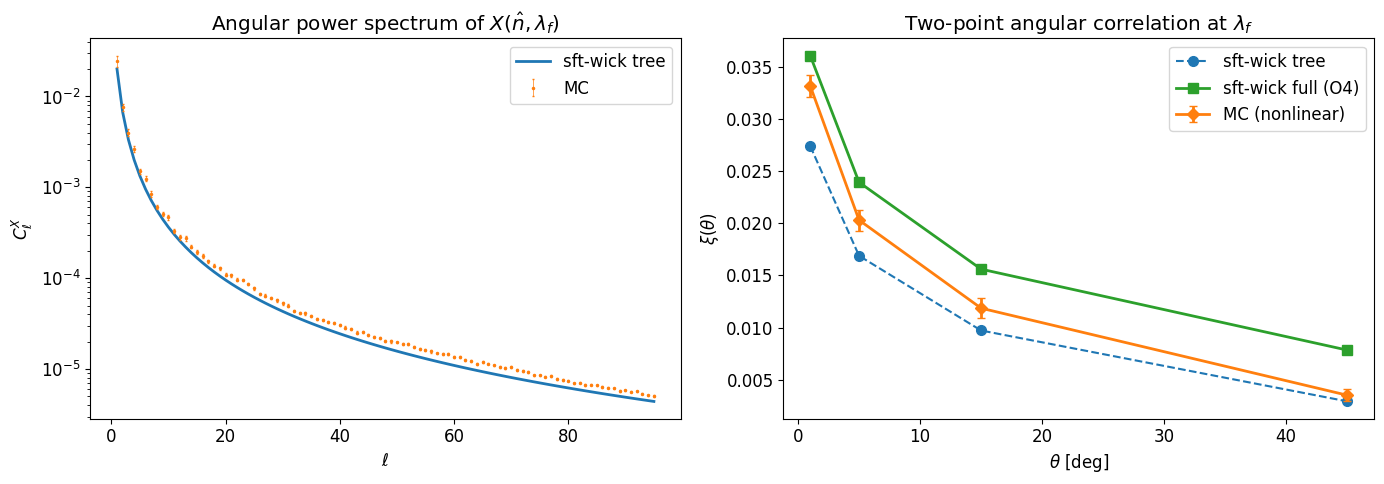

In [67]:
# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- C_ell comparison ---
ax = axes[0]
ells_plot = np.arange(1, lmax + 1)
ax.plot(ells_plot, Cl_X_tree[1:], 'C0-', lw=2, label='sft-wick tree')
ax.errorbar(ells_plot, Cl_mean[1:], yerr=Cl_err[1:], fmt='C1.', ms=3,
            capsize=1, elinewidth=0.5, label='MC')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$C_\ell^X$')
ax.set_title(r'Angular power spectrum of $X(\hat{n}, \lambda_f)$')
ax.legend()
ax.set_yscale('log')

# --- xi(theta) comparison ---
ax = axes[1]
ax.plot(theta_deg, xi_wick_tree, 'C0o--', lw=1.5, ms=7, label='sft-wick tree')
ax.plot(theta_deg, xi_wick, 'C2s-', lw=2, ms=7, label=f'sft-wick full (O{perturbative_order})')
ax.errorbar(theta_deg, xi_mc, yerr=xi_mc_err, fmt='C1D-', lw=2, ms=6,
            capsize=3, label='MC (nonlinear)')
ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$\xi(\theta)$')
ax.set_title(r'Two-point angular correlation at $\lambda_f$')
ax.legend()

plt.tight_layout()
plt.show()

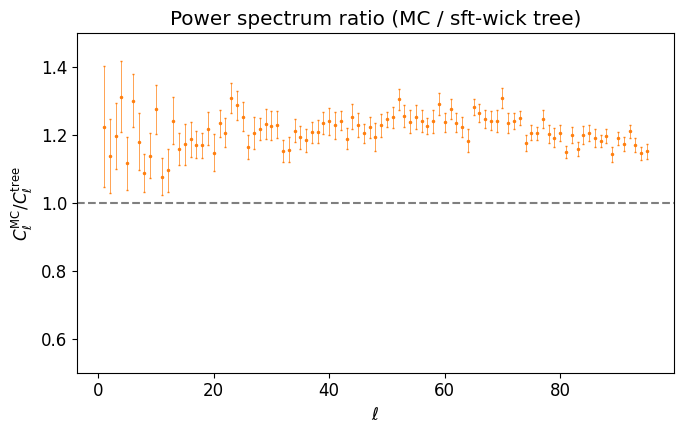

In [68]:
# --- C_ell ratio plot (MC / tree) ---
fig, ax = plt.subplots(figsize=(7, 4.5))

ratio = Cl_mean[1:] / Cl_X_tree[1:]
ratio_err = Cl_err[1:] / Cl_X_tree[1:]

ax.errorbar(ells_plot, ratio, yerr=ratio_err, fmt='C1.', ms=3,
            capsize=1, elinewidth=0.5)
ax.axhline(1.0, color='k', ls='--', alpha=0.5)
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$C_\ell^{\rm MC} / C_\ell^{\rm tree}$')
ax.set_title('Power spectrum ratio (MC / sft-wick tree)')
ax.set_ylim(0.5, 1.5)

plt.tight_layout()
plt.show()

## 9. $\xi(\theta)$ Evolution with $\lambda$

Track how the two-point correlation builds up as the integration endpoint $\lambda$ increases, comparing sft-wick tree level with MC at several angular separations.

In [69]:
# --- Tree-level xi(theta, lambda) evolution ---
# C_corr_integral(lam) = integral_0^lam integral_0^lam C_corr(t,t') dt dt'
# Compute via cumulative sum on the table grid.

N_ckpt = 8
lam_checkpoints = np.linspace(lam_start + 100, lam_f, N_ckpt)

# For each checkpoint, compute the double integral up to that lambda
C_corr_integral_ckpt = np.zeros(N_ckpt)
for ic, lam_c in enumerate(lam_checkpoints):
    # Truncate the table to [0, lam_c]
    mask = ts <= lam_c
    ts_c = ts[mask]
    C_sub = C_corr_table[np.ix_(mask, mask)]
    dt_c = ts_c[1] - ts_c[0] if len(ts_c) > 1 else 1.0
    C_corr_integral_ckpt[ic] = np.sum(C_sub) * dt_c**2

# Tree-level xi at each (theta, lambda) checkpoint
xi_tree_ckpt = np.outer(S_vals, C_corr_integral_ckpt)  # (n_theta, n_ckpt)

print('Tree-level xi(theta, lambda) computed at', N_ckpt, 'checkpoints')
print(f'C_corr integral range: [{C_corr_integral_ckpt[0]:.4e}, {C_corr_integral_ckpt[-1]:.4e}]')

Tree-level xi(theta, lambda) computed at 8 checkpoints
C_corr integral range: [6.4870e+05, 4.0144e+10]


In [70]:
# --- sft-wick loop corrections (O2 + O4) at each lambda checkpoint ---
n1_vec_evo = np.array([0.0, 0.0, 1.0])
n_samples_evo = {2: 2**13, 4: 2**11}  # fewer samples for speed

dts_o2 = result_2pt.diagram_terms(2)
dts_o4 = result_2pt.diagram_terms(4)
n_int = N_ckpt * len(theta_rad) * (len(dts_o2) + len(dts_o4))
print(f'Computing O2+O4 corrections at {N_ckpt} checkpoints x {len(theta_rad)} angles')
print(f'  O2: {len(dts_o2)} diagrams, O4: {len(dts_o4)} diagrams, total {n_int} integrations')

xi_wick_o2_ckpt = np.zeros((len(theta_rad), N_ckpt))   # tree + O2
xi_wick_full_ckpt = np.zeros((len(theta_rad), N_ckpt))  # tree + O2 + O4

t0_loop = time.time()
for ic, lam_c in enumerate(lam_checkpoints):
    t_ic = time.time()
    for i_th, th in enumerate(theta_rad):
        n2_vec_evo = np.array([np.sin(th), 0.0, np.cos(th)])
        
        tree_val = xi_tree_ckpt[i_th, ic]
        
        # Order 2
        o2_total = 0.0
        for dt in dts_o2:
            ig = dt.build_integrand({'F': F_code})
            dirs = make_two_point_directions(ig.spatial, n1_vec_evo, n2_vec_evo)
            val, _ = integrate_two_point_qmc(
                ig, lam_c, two_pt_cache, dirs,
                t_min=epsilon, n_samples=n_samples_evo[2],
            )
            o2_total += val
        
        # Order 4
        o4_total = 0.0
        for dt in dts_o4:
            ig = dt.build_integrand({'F': F_code})
            dirs = make_two_point_directions(ig.spatial, n1_vec_evo, n2_vec_evo)
            val, _ = integrate_two_point_qmc(
                ig, lam_c, two_pt_cache, dirs,
                t_min=epsilon, n_samples=n_samples_evo[4],
            )
            o4_total += val
        
        xi_wick_o2_ckpt[i_th, ic] = tree_val + o2_total
        xi_wick_full_ckpt[i_th, ic] = tree_val + o2_total + o4_total
    
    print(f'  checkpoint {ic+1}/{N_ckpt}: lam={lam_c:.0f} ({time.time()-t_ic:.1f}s), '
          f'O2={xi_wick_o2_ckpt[1,ic]-xi_tree_ckpt[1,ic]:+.3e}, '
          f'O4={xi_wick_full_ckpt[1,ic]-xi_wick_o2_ckpt[1,ic]:+.3e}')

print(f'\nLoop evolution done in {time.time()-t0_loop:.1f}s')

Computing O2+O4 corrections at 8 checkpoints x 4 angles
  O2: 6 diagrams, O4: 64 diagrams, total 2240 integrations
  checkpoint 1/8: lam=100 (28.6s), O2=+9.407e-13, O4=+1.054e-18
  checkpoint 2/8: lam=514 (29.0s), O2=+2.265e-08, O4=+3.572e-12
  checkpoint 3/8: lam=929 (29.3s), O2=+8.875e-07, O4=+8.823e-10
  checkpoint 4/8: lam=1343 (29.7s), O2=+9.578e-06, O4=+2.927e-08
  checkpoint 5/8: lam=1757 (30.2s), O2=+6.082e-05, O4=+5.383e-07
  checkpoint 6/8: lam=2171 (30.6s), O2=+3.007e-04, O4=+5.331e-06
  checkpoint 7/8: lam=2586 (31.0s), O2=+1.346e-03, O4=+7.492e-05
  checkpoint 8/8: lam=3000 (31.4s), O2=+6.251e-03, O4=+6.329e-04

Loop evolution done in 239.8s


In [71]:
# --- MC xi(theta, lambda) evolution ---
N_seeds_evo = 10

# Map checkpoints to indices in lam_samples
ckpt_indices = np.searchsorted(lam_samples, lam_checkpoints)
ckpt_indices = np.clip(ckpt_indices, 0, len(lam_samples) - 1)

# Per-seed xi at each checkpoint
xi_mc_ckpt_per_seed = np.zeros((N_ckpt, N_seeds_evo, len(theta_rad)))

t0_evo = time.time()
for seed in range(N_seeds_evo):
    source = sf.FullSkySource(
        cl_func=cl_func, lam_samples=lam_samples, nside=nside,
        corr_func=corr_func, seed=seed, n_fields=3,
    )
    source.generate()
    delta_s = source.delta_s_interpolator()
    
    fl = FluctuationSolver(
        theta_saddle, delta_s, source.npix,
        n_fields=3, linear_only=False,
        lam_span=(lam_start, lam_f),
        method='RK45', rtol=1e-6, atol=1e-12,
    )
    result_mc = fl.solve(t_eval=lam_samples)
    xi1 = result_mc.xi[:, 0, :]  # (n_lam, npix)
    
    for ic, idx in enumerate(ckpt_indices):
        X_map = np.trapezoid(xi1[:idx+1], x=lam_samples[:idx+1], axis=0)
        cl = hp.anafast(X_map, lmax=lmax)
        xi_mc_ckpt_per_seed[ic, seed] = P_ell_matrix @ cl
    
    if seed % 5 == 0:
        print(f'seed={seed} done')

print(f'MC evolution done in {time.time()-t0_evo:.1f}s')

# Average over seeds
xi_mc_ckpt = np.mean(xi_mc_ckpt_per_seed, axis=1)      # (N_ckpt, n_theta)
xi_mc_ckpt_err = np.std(xi_mc_ckpt_per_seed, axis=1) / np.sqrt(N_seeds_evo)

# Transpose for plotting: (n_theta, N_ckpt)
xi_mc_ckpt = xi_mc_ckpt.T
xi_mc_ckpt_err = xi_mc_ckpt_err.T

seed=0 done
seed=5 done
MC evolution done in 46.5s


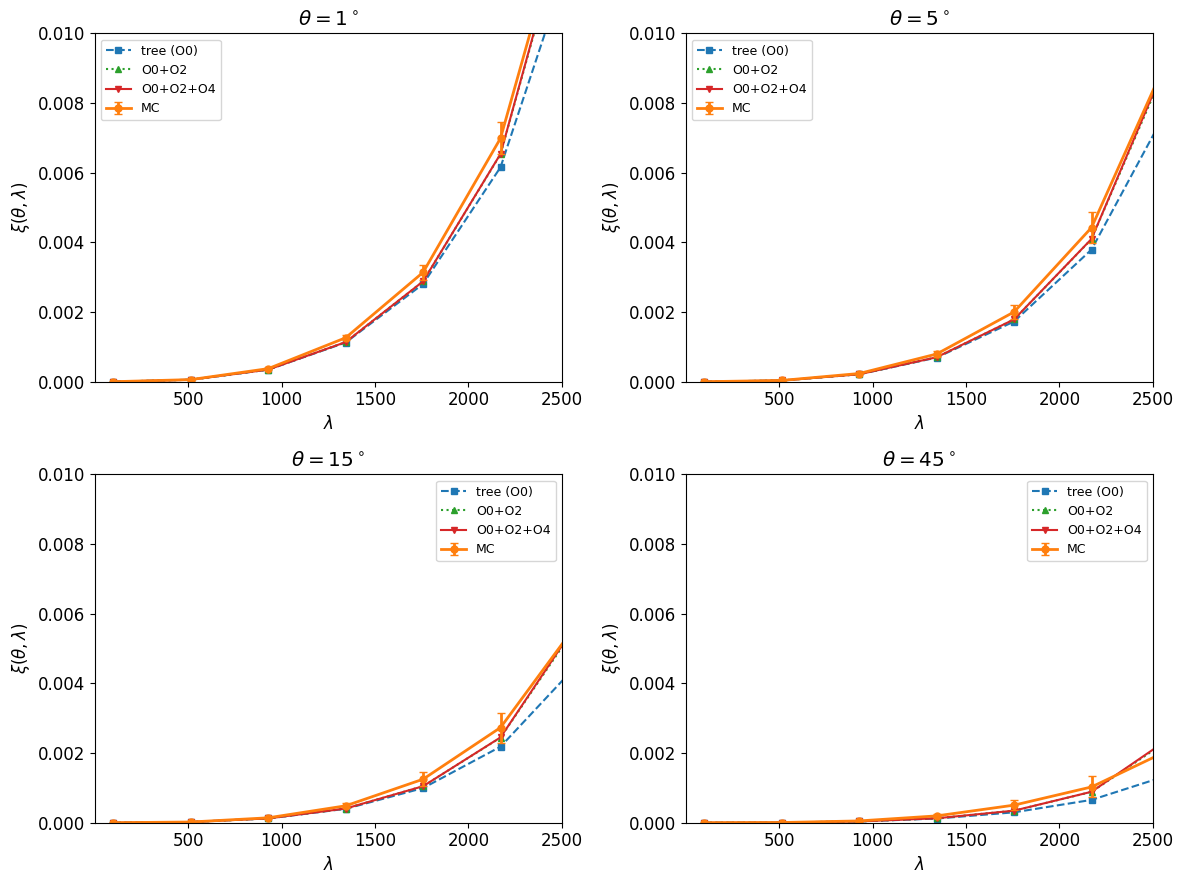

In [76]:
# --- Evolution plot: xi(theta, lambda) ---
n_cols = 2
n_rows = (len(theta_rad) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes = axes.ravel()

for i_th in range(len(theta_rad)):
    ax = axes[i_th]
    th_label = f'{theta_deg[i_th]:.0f}'
    
    # Tree-level
    ax.plot(lam_checkpoints, xi_tree_ckpt[i_th], 'C0s--', lw=1.5, ms=5,
            label='tree (O0)')
    # Tree + O2
    ax.plot(lam_checkpoints, xi_wick_o2_ckpt[i_th], 'C2^:', lw=1.5, ms=5,
            label='O0+O2')
    # Tree + O2 + O4
    ax.plot(lam_checkpoints, xi_wick_full_ckpt[i_th], 'C3v-', lw=1.5, ms=5,
            label='O0+O2+O4')
    # MC
    ax.errorbar(lam_checkpoints, xi_mc_ckpt[i_th], yerr=xi_mc_ckpt_err[i_th],
                fmt='C1o-', lw=2, ms=5, capsize=3, label='MC')
    
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\xi(\theta, \lambda)$')
    ax.set_xlim(lam_start, 2500)
    ax.set_ylim(0, 0.01)
#     ax.set_yscale('symlog', linthresh=1e-6)
    ax.set_title(rf'$\theta = {th_label}^\circ$')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 10. Summary

In [73]:
print('='*70)
print('TWO-POINT CORRELATION CROSS-CHECK — SUMMARY')
print('='*70)
print(f'Model: C_l = A/(l(l+1)) * exp(-c*(lam1-lam2)^2)')
print(f'  A = {A:.2e}, c = {c}, sbar_1 = {sbar_1:.2e}')
print(f'  lam_f = {lam_f}, lam_start(MC) = {lam_start}, lmax = {lmax}')
print(f'  S0 = {S0:.4e}')
print(f'MC: {N_seeds} realizations x {npix} pixels, nonlinear FluctuationSolver')
print(f'sft-wick: perturbative order {perturbative_order}')
print(f'  Order 0: 1 diagram, Order 2: 6 diagrams, Order 4: 64 diagrams')
print()
print(f'Angular separations: {theta_deg} deg')
print()
print(f'{"theta":>8} | {"tree":>14} | {"wick full":>14} | {"MC":>14} | {"sigma":>6}')
print('-' * 70)
for i_th in range(len(theta_rad)):
    wt = xi_wick_tree[i_th]
    w = xi_wick[i_th]
    m = xi_mc[i_th]
    e = xi_mc_err[i_th]
    sig = abs(w - m) / e if e > 0 else 0
    print(f'{theta_deg[i_th]:>6.1f}\u00b0 | {wt:+14.6e} | {w:+14.6e} | {m:+14.6e} | {sig:6.1f}')
print('='*70)

TWO-POINT CORRELATION CROSS-CHECK — SUMMARY
Model: C_l = A/(l(l+1)) * exp(-c*(lam1-lam2)^2)
  A = 1.00e-12, c = 0.01, sbar_1 = -1.00e-06
  lam_f = 3000.0, lam_start(MC) = 0.1, lmax = 95
  S0 = 7.3873e-13
MC: 30 realizations x 12288 pixels, nonlinear FluctuationSolver
sft-wick: perturbative order 4
  Order 0: 1 diagram, Order 2: 6 diagrams, Order 4: 64 diagrams

Angular separations: [ 1.  5. 15. 45.] deg

   theta |           tree |      wick full |             MC |  sigma
----------------------------------------------------------------------
   1.0° |  +2.740449e-02 |  +3.608643e-02 |  +3.317848e-02 |    2.8
   5.0° |  +1.688081e-02 |  +2.393378e-02 |  +2.030598e-02 |    3.6
  15.0° |  +9.714899e-03 |  +1.560100e-02 |  +1.185481e-02 |    4.0
  45.0° |  +2.915579e-03 |  +7.834682e-03 |  +3.505058e-03 |    7.3
